# 🔬 Autopsia Matemática del Kinetopus Engine
---
## Notebook de Inspección Forense del Pipeline Completo

Este notebook abre el motor **Kinetopus Engine** en canal para exponer, paso a paso, cómo se transmutan los datos financieros crudos en ecuaciones diferenciales estocásticas y proyecciones Monte Carlo.

**Activo canónico:** `BTC-USD` (Bitcoin) | **Periodo:** `1y` | **Intervalo:** `1h`

### Objetivo Triple:
1. **Auto-auditoría:** Rastrear exactamente dónde atacar en una futura reformulación estructural.
2. **Transparencia científica:** Verificar que no hay "magia negra" en el motor.
3. **Documentación viva:** Referencia técnica replicable de toda la arquitectura.

> ⚠️ **Nota:** Este notebook es un ejercicio educativo. Las proyecciones NO constituyen asesoramiento financiero.

In [1]:
# === CONFIGURACIÓN DEL LABORATORIO ===
import sys
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib import cm

# Silenciar warnings no críticos para mantener la salida limpia
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Configurar el path para importar los módulos del motor usando pathlib
from pathlib import Path
current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks_val' else current_dir

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Importar los módulos internos del Kinetopus Engine
from src.ui.market_loader import MarketLoader
from src.quant_engine.sensor import SpectralAnalyzer
from src.quant_engine.blender import ContinuousBlender
from src.quant_engine.nervous import RegimeShiftDetector
from src.quant_engine.physics import PhysicsDiscoverer
from src.quant_engine.symbolic import SymbolicTranslator

# Estilo visual oscuro (coherente con el Dashboard del motor)
plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("✅ Laboratorio configurado correctamente.")
print(f"   NumPy: {np.__version__}")
print(f"   Raíz del proyecto: {PROJECT_ROOT}")

✅ Laboratorio configurado correctamente.
   NumPy: 2.4.2
   Raíz del proyecto: c:\Users\ussaa\Documents\KineTopus Engine


In [2]:
# === CARGA DE DATOS CRUDOS: BTC-USD ===
TICKER = "BTC-USD"
PERIOD = "1y"
INTERVAL = "1h"

df = MarketLoader.load_ticker_data(TICKER, period=PERIOD, interval=INTERVAL)

print(f"📊 Datos cargados: {TICKER}")
print(f"   Filas: {len(df)} velas | Columnas: {list(df.columns)}")
print(f"   Rango temporal: {df.index[0]} → {df.index[-1]}")
print(f"\n--- Primeras 5 filas ---")
df.head()

📊 Datos cargados: BTC-USD
   Filas: 8593 velas | Columnas: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
   Rango temporal: 2025-05-20 13:00:00+00:00 → 2026-05-20 13:00:00+00:00

--- Primeras 5 filas ---


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2025-05-20 13:00:00+00:00,104809.375000,104853.453125,104206.515625,104472.148438,0,0.0,0.0
2025-05-20 14:00:00+00:00,104459.195312,104980.390625,104333.343750,104564.710938,0,0.0,0.0
2025-05-20 15:00:00+00:00,104560.609375,105399.671875,104560.609375,105382.179688,0,0.0,0.0
2025-05-20 16:00:00+00:00,105364.250000,105501.570312,105150.828125,105231.078125,0,0.0,0.0
2025-05-20 17:00:00+00:00,105228.703125,106332.695312,105228.703125,106229.726562,308580352,0.0,0.0


---
# 📋 ACTO 1: Sanitización y Transformación
## La Puerta de Entrada al Motor

Antes de que el motor pueda "escuchar" al mercado, los datos crudos deben pasar por una transformación fundamental:

**Retorno Logarítmico:**
$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Esto convierte los precios absolutos (ej. $67,000 USD) en variaciones relativas microscópicas centradas en cero (ej. ±0.003), eliminando la escala absoluta y permitiendo el cálculo diferencial.

**Volumen Z-Score:**
$$V_z = \frac{V - \mu_V}{\sigma_V}$$

Normaliza el volumen a desviaciones estándar, haciéndolo comparable entre activos y periodos.

In [3]:
# === EJECUTAR LA SANITIZACIÓN ===
log_returns, volumen_z, precio_raw, dt = MarketLoader.prepare_quant_input(df)
t = np.arange(len(log_returns), dtype=np.float64) * dt

# --- TABLA DE INSPECCIÓN DIMENSIONAL ---
print("=" * 65)
print("  INSPECCIÓN DIMENSIONAL POST-SANITIZACIÓN")
print("=" * 65)
print(f"  log_returns  → shape: {log_returns.shape}, dtype: {log_returns.dtype}")
print(f"                 rango: [{log_returns.min():.6f}, {log_returns.max():.6f}]")
print(f"  volumen_z    → shape: {volumen_z.shape}, dtype: {volumen_z.dtype}")
print(f"                 rango: [{volumen_z.min():.4f}, {volumen_z.max():.4f}]")
print(f"  precio_raw   → shape: {precio_raw.shape}")
print(f"                 rango: [{precio_raw.min():.2f}, {precio_raw.max():.2f}]")
print(f"  dt           → {dt} (1 vela = 1 unidad de tiempo)")
print(f"  t            → shape: {t.shape}, rango: [{t[0]}, {t[-1]}]")
print("=" * 65)

  INSPECCIÓN DIMENSIONAL POST-SANITIZACIÓN
  log_returns  → shape: (8593,), dtype: float64
                 rango: [-0.140029, 0.032997]
  volumen_z    → shape: (8593,), dtype: float64
                 rango: [-0.3458, 29.5117]
  precio_raw   → shape: (8593,)
                 rango: [62704.45, 126149.02]
  dt           → 1.0 (1 vela = 1 unidad de tiempo)
  t            → shape: (8593,), rango: [0.0, 8592.0]


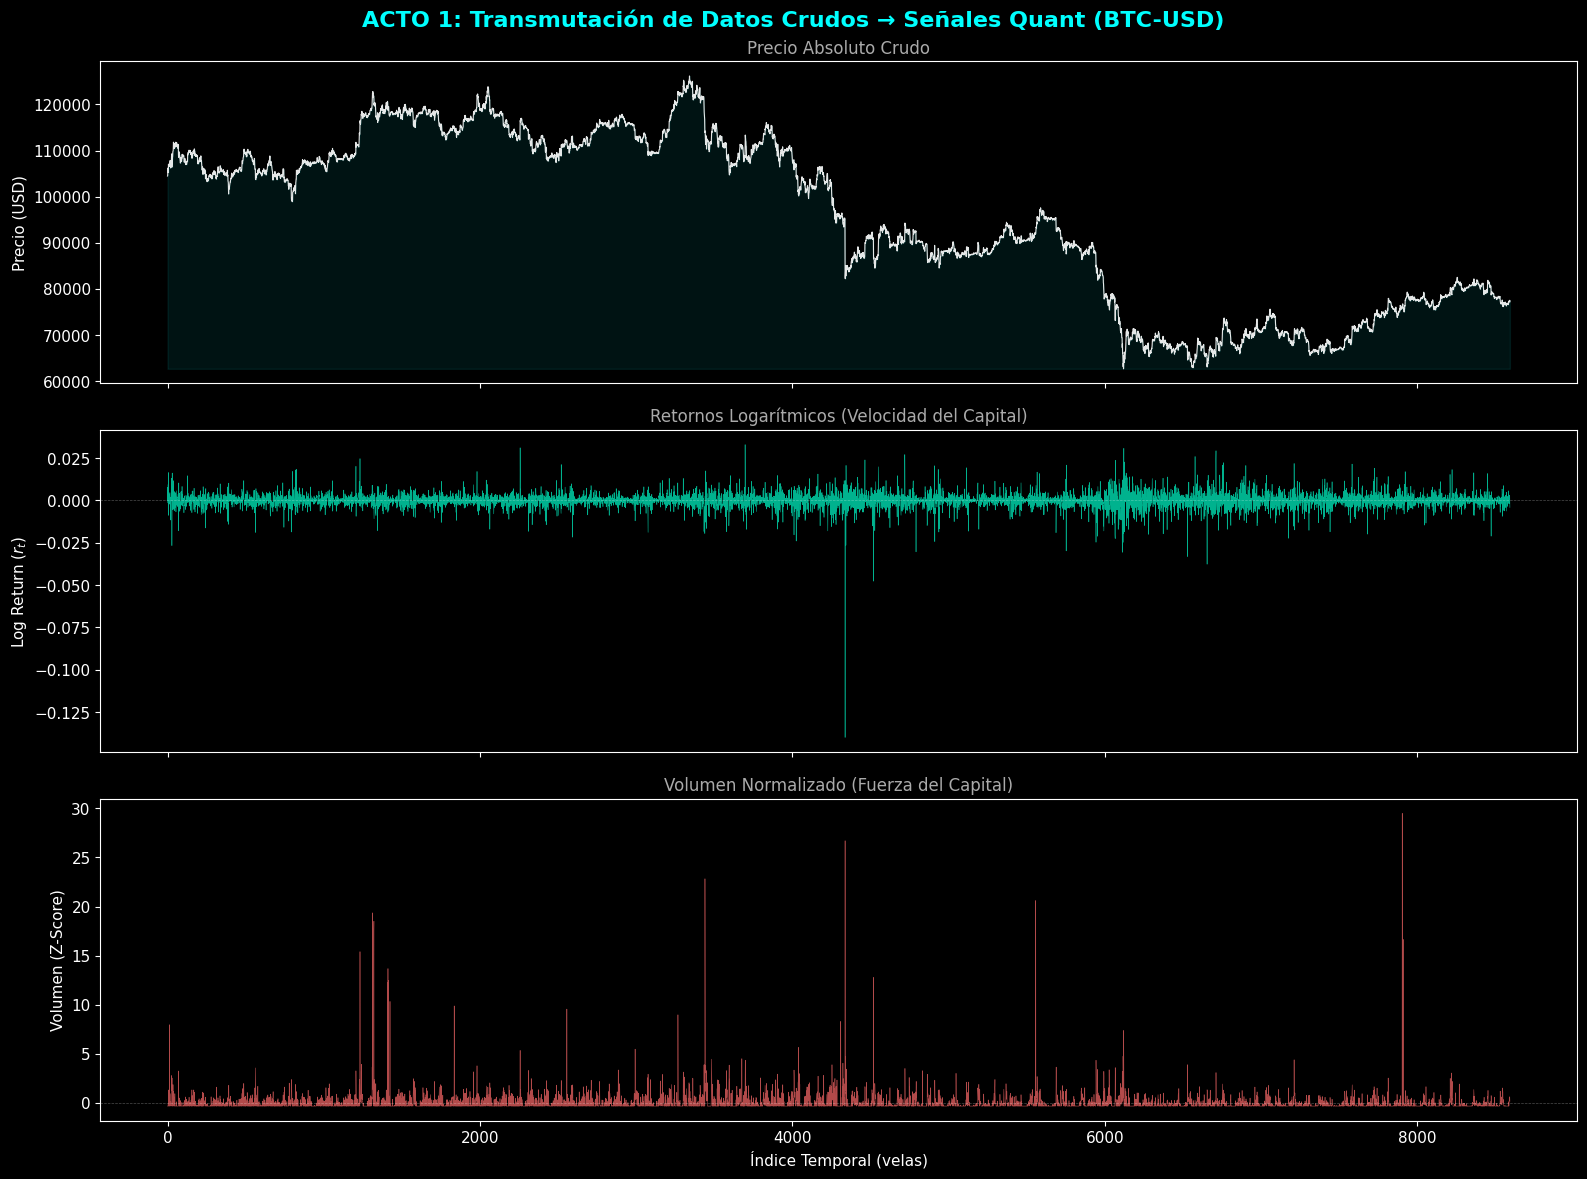

👁️ Observa: El precio ($67k+) se ha convertido en retornos microscópicos (±0.005) centrados en cero.


In [4]:
# === VISUALIZACIÓN: De Precio Absoluto a Retorno Logarítmico ===
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle(f'ACTO 1: Transmutación de Datos Crudos → Señales Quant ({TICKER})', 
             fontsize=16, fontweight='bold', color='cyan')

# Subplot 1: Precio Absoluto
axes[0].plot(t, precio_raw, color='#FFFFFF', linewidth=0.8, alpha=0.9)
axes[0].set_ylabel('Precio (USD)', fontsize=11)
axes[0].set_title('Precio Absoluto Crudo', fontsize=12, color='#AAAAAA')
axes[0].fill_between(t, precio_raw.min(), precio_raw, alpha=0.08, color='cyan')

# Subplot 2: Retornos Logarítmicos
axes[1].plot(t, log_returns, color='#00FFCC', linewidth=0.4, alpha=0.7)
axes[1].axhline(y=0, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
axes[1].set_ylabel('Log Return ($r_t$)', fontsize=11)
axes[1].set_title('Retornos Logarítmicos (Velocidad del Capital)', fontsize=12, color='#AAAAAA')

# Subplot 3: Volumen Z-Score
axes[2].plot(t, volumen_z, color='#FF6B6B', linewidth=0.4, alpha=0.7)
axes[2].axhline(y=0, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
axes[2].set_ylabel('Volumen (Z-Score)', fontsize=11)
axes[2].set_title('Volumen Normalizado (Fuerza del Capital)', fontsize=12, color='#AAAAAA')
axes[2].set_xlabel('Índice Temporal (velas)', fontsize=11)

plt.tight_layout()
plt.show()

print("👁️ Observa: El precio ($67k+) se ha convertido en retornos microscópicos (±0.005) centrados en cero.")

---
# 📋 ACTO 2: Sensor Espectral — FFT (Capa 1)
## Descubriendo la Respiración Oculta del Mercado

La **Transformada Rápida de Fourier (FFT)** descompone la señal temporal en sus frecuencias constituyentes. Imagina que el mercado "suena" como una orquesta caótica; la FFT identifica qué "notas musicales" (ciclos) suenan más fuerte.

**¿Qué buscamos?** Los Top-K períodos dominantes: ¿cada cuántas velas se repite un patrón cíclico en los retornos y en el volumen?

### Proceso Interno:
1. Centrar la señal (remover la componente DC / media)
2. Aplicar `np.fft.rfft()` (FFT real)
3. Calcular el Power Spectral Density: $PSD = |FFT|^2$
4. Identificar los Top-K picos de potencia
5. Convertir frecuencia → período: $T = 1/f$

In [5]:
# === EJECUTAR EL SENSOR ESPECTRAL (FFT) ===
sensor = SpectralAnalyzer(top_k=2)
data_matrix = np.column_stack((log_returns, volumen_z))

print(f"📐 Matriz de entrada al Sensor: shape = {data_matrix.shape}  (N velas × 2 canales)")

fft_results = sensor.analyze(data_matrix, dt=dt)

periodos_retornos = fft_results[0]['periods']
amplitudes_retornos = fft_results[0]['amplitudes']
periodos_volumen = fft_results[1]['periods']
amplitudes_volumen = fft_results[1]['amplitudes']

# --- TABLA DE RESULTADOS FFT ---
print("\n" + "=" * 65)
print("  RESULTADOS DEL SENSOR ESPECTRAL (FFT)")
print("=" * 65)
print(f"  Canal 0 (Retornos):")
for i, (p, a) in enumerate(zip(periodos_retornos, amplitudes_retornos)):
    print(f"    Período Top-{i+1} = {p:.1f} velas | Amplitud = {a:.6f}")
print(f"  Canal 1 (Volumen):")
for i, (p, a) in enumerate(zip(periodos_volumen, amplitudes_volumen)):
    print(f"    Período Top-{i+1} = {p:.1f} velas | Amplitud = {a:.4f}")
print("=" * 65)
print(f"  Runtime: {fft_results[0]['runtime_ms']:.2f} ms (Retornos), {fft_results[1]['runtime_ms']:.2f} ms (Volumen)")

📐 Matriz de entrada al Sensor: shape = (8593, 2)  (N velas × 2 canales)

  RESULTADOS DEL SENSOR ESPECTRAL (FFT)
  Canal 0 (Retornos):
    Período Top-1 = 5.1 velas | Amplitud = 1.206981
    Período Top-2 = 4.6 velas | Amplitud = 1.149633
  Canal 1 (Volumen):
    Período Top-1 = 84.2 velas | Amplitud = 678.2119
    Período Top-2 = 8593.0 velas | Amplitud = 465.2292
  Runtime: 9.02 ms (Retornos), 6.13 ms (Volumen)


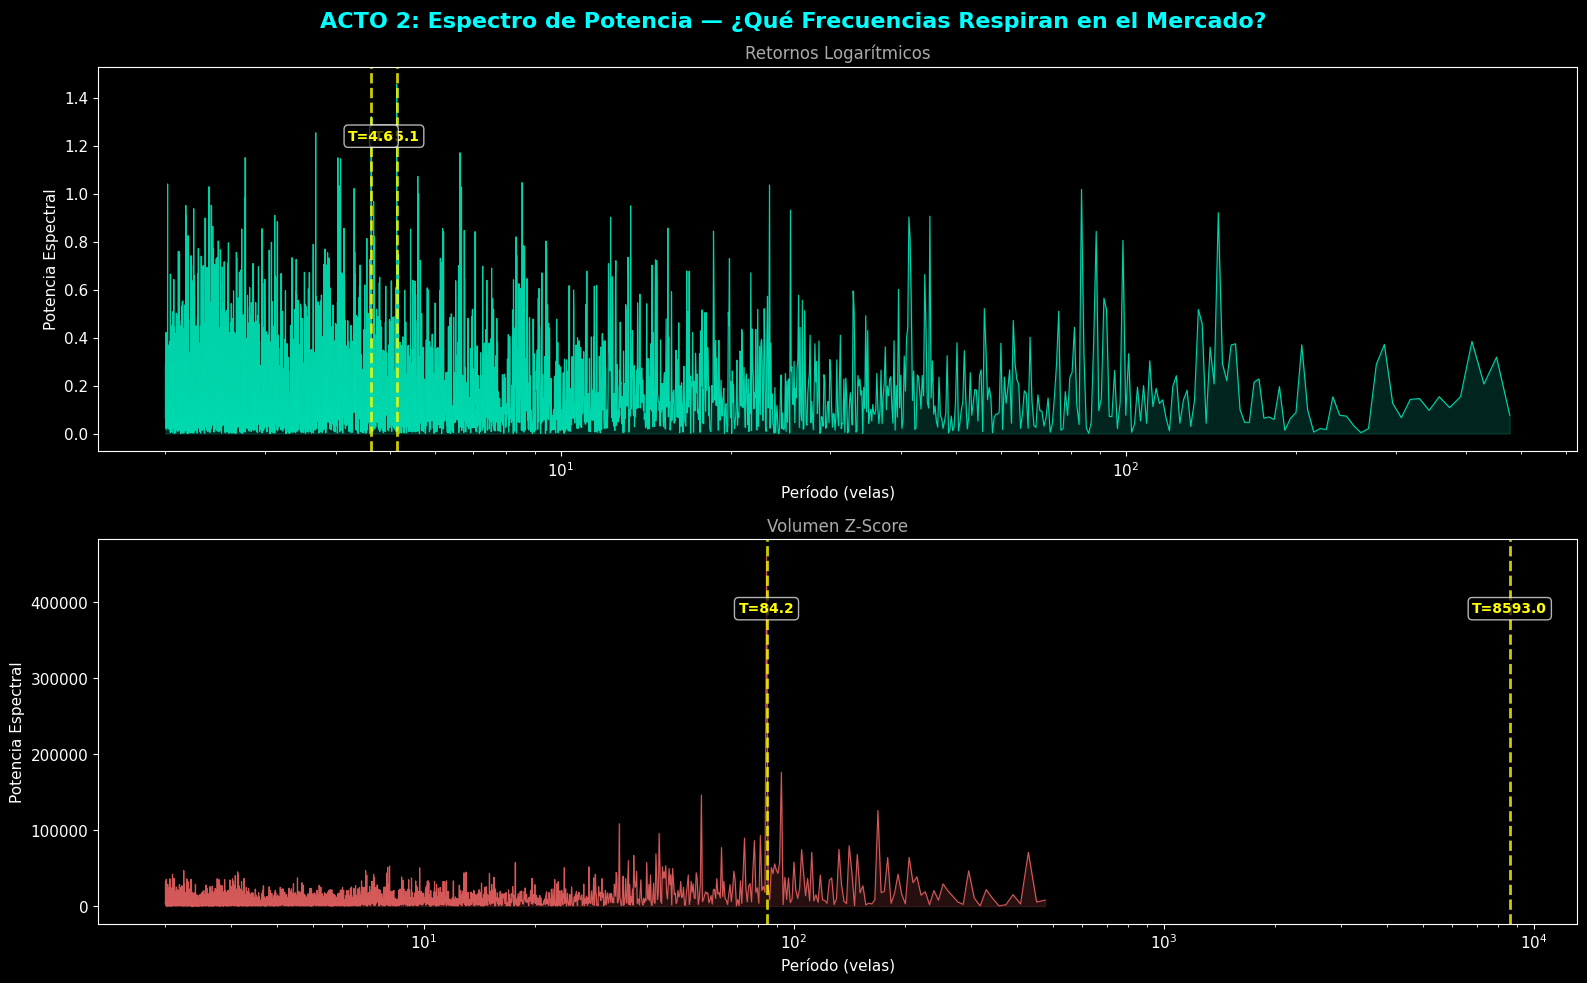

👁️ Los picos amarillos son las 'notas dominantes'. Estos períodos informan al Spline cómo suavizar.


In [6]:
# === VISUALIZACIÓN: Espectro de Potencia (PSD) ===
# Replicamos el cálculo interno de _compute_fft para visualizar el espectro completo

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('ACTO 2: Espectro de Potencia — ¿Qué Frecuencias Respiran en el Mercado?', 
             fontsize=16, fontweight='bold', color='cyan')

for idx, (signal, label, color, periodos) in enumerate([
    (log_returns, 'Retornos Logarítmicos', '#00FFCC', periodos_retornos),
    (volumen_z, 'Volumen Z-Score', '#FF6B6B', periodos_volumen)
]):
    # FFT manual para visualización
    centered = signal - np.mean(signal)
    fft_vals = np.fft.rfft(centered)
    freqs = np.fft.rfftfreq(len(signal), d=dt)
    power = np.abs(fft_vals) ** 2
    power[0] = 0  # Kill DC
    
    # Convertir a períodos (más intuitivo)
    valid = freqs[1:] > 0
    periods_axis = 1.0 / freqs[1:][valid]
    power_axis = power[1:][valid]
    
    # Solo mostrar períodos razonables (2 a 500 velas)
    mask = (periods_axis >= 2) & (periods_axis <= 500)
    
    axes[idx].plot(periods_axis[mask], power_axis[mask], color=color, linewidth=0.8, alpha=0.8)
    axes[idx].fill_between(periods_axis[mask], 0, power_axis[mask], alpha=0.15, color=color)
    
    # Marcar los Top-K períodos con líneas verticales
    for p in periodos:
        if p > 0:
            axes[idx].axvline(x=p, color='yellow', linewidth=2, linestyle='--', alpha=0.8)
            axes[idx].annotate(f'T={p:.1f}', xy=(p, axes[idx].get_ylim()[1]*0.8), 
                             fontsize=10, color='yellow', fontweight='bold',
                             ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    axes[idx].set_title(f'{label}', fontsize=12, color='#AAAAAA')
    axes[idx].set_xlabel('Período (velas)', fontsize=11)
    axes[idx].set_ylabel('Potencia Espectral', fontsize=11)
    axes[idx].set_xscale('log')

plt.tight_layout()
plt.show()

print("👁️ Los picos amarillos son las 'notas dominantes'. Estos períodos informan al Spline cómo suavizar.")

---
# 📋 ACTO 3: Moldeador Topológico — Splines $C^2$ (Capa 2)
## Destruyendo la Discretización: Del Ruido a la Sábana Continua

El cálculo diferencial (derivadas) requiere funciones continuas. Pero las velas del mercado son **datos discretos** — puntos aislados donde la derivada numérica genera saltos infinitos e irreales.

### La Solución: Splines Cúbicos ($C^2$)
Un `UnivariateSpline` de SciPy "plancha" los puntos ruidosos creando una **sábana matemática infinitamente suave**. De esta superficie continua extraemos derivadas **analíticas exactas** (no numéricas).

### El Parámetro de Suavizado:
$$s = T_{\text{período\_top}} \times N \times \text{tolerancia} \times 0.1$$

Donde $T$ es el período dominante de la FFT. Así, la FFT le "dice" al Spline cómo de ancha debe ser su brocha.

### Las 6 señales que nacen:
| Variable | Símbolo | Significado Físico |
|---|---|---|
| `r_smooth` | $r$ | Posición suavizada (Inercia) |
| `r_dot` | $\dot{r}$ | 1ª Derivada = Velocidad |
| `r_dot2` | $\ddot{r}$ | 2ª Derivada = Aceleración |
| `v_smooth` | $V$ | Volumen suavizado |
| `v_dot` | $\dot{V}$ | Cambio del volumen |
| `v_dot2` | $\ddot{V}$ | Aceleración del volumen |

In [7]:
# === EJECUTAR EL MOLDEADOR TOPOLÓGICO (SPLINES) ===
SMOOTH_TOL = 0.005   # Tolerancia de Aislamiento (parámetro del UI slider)

blender = ContinuousBlender(tolerance=SMOOTH_TOL)

# Ajustar los Splines usando la información de la FFT
telemetry_r = blender.fit(t, log_returns, periodos_retornos, feature_idx=0)
telemetry_v = blender.fit(t, volumen_z, periodos_volumen, feature_idx=1)

# Extraer las 6 señales continuas
r_smooth, r_dot, r_dot2 = blender.compute_continuous(0, t)
v_smooth, v_dot, v_dot2 = blender.compute_continuous(1, t)

# --- TABLA DIMENSIONAL DE LAS 6 SEÑALES ---
print("=" * 70)
print("  INSPECCIÓN: LAS 6 SEÑALES CONTINUAS DEL MOLDEADOR TOPOLÓGICO")
print("=" * 70)
signals = [
    ("r_smooth (Posición)", r_smooth),
    ("r_dot    (Velocidad)", r_dot),
    ("r_dot2   (Aceleración)", r_dot2),
    ("v_smooth (Vol. Suavizado)", v_smooth),
    ("v_dot    (Cambio Vol.)", v_dot),
    ("v_dot2   (Acel. Vol.)", v_dot2),
]
for name, sig in signals:
    print(f"  {name:30s} → shape: {sig.shape}, rango: [{sig.min():.6f}, {sig.max():.6f}]")
print(f"\n  MSE del Spline (Retornos): {telemetry_r['mse']:.10f}")
print(f"  MSE del Spline (Volumen):  {telemetry_v['mse']:.6f}")
print("=" * 70)

  INSPECCIÓN: LAS 6 SEÑALES CONTINUAS DEL MOLDEADOR TOPOLÓGICO
  r_smooth (Posición)            → shape: (8593,), rango: [-0.000130, 0.000161]
  r_dot    (Velocidad)           → shape: (8593,), rango: [-0.000000, 0.000000]
  r_dot2   (Aceleración)         → shape: (8593,), rango: [-0.000000, 0.000000]
  v_smooth (Vol. Suavizado)      → shape: (8593,), rango: [-0.133351, 0.095353]
  v_dot    (Cambio Vol.)         → shape: (8593,), rango: [-0.000058, 0.000160]
  v_dot2   (Acel. Vol.)          → shape: (8593,), rango: [-0.000000, 0.000000]

  MSE del Spline (Retornos): 0.0000216604
  MSE del Spline (Volumen):  0.994203


<>:16: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:22: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:16: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:22: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\ussaa\AppData\Local\Temp\ipykernel_13788\2612280348.py:16: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  axes[1].set_ylabel('$\dot{r}(t)$', fontsize=13)
C:\Users\ussaa\AppData\Local\Temp\ipykernel_13788\2612280348.py:22: SyntaxWarning: "\d" is an invalid escape sequence. 

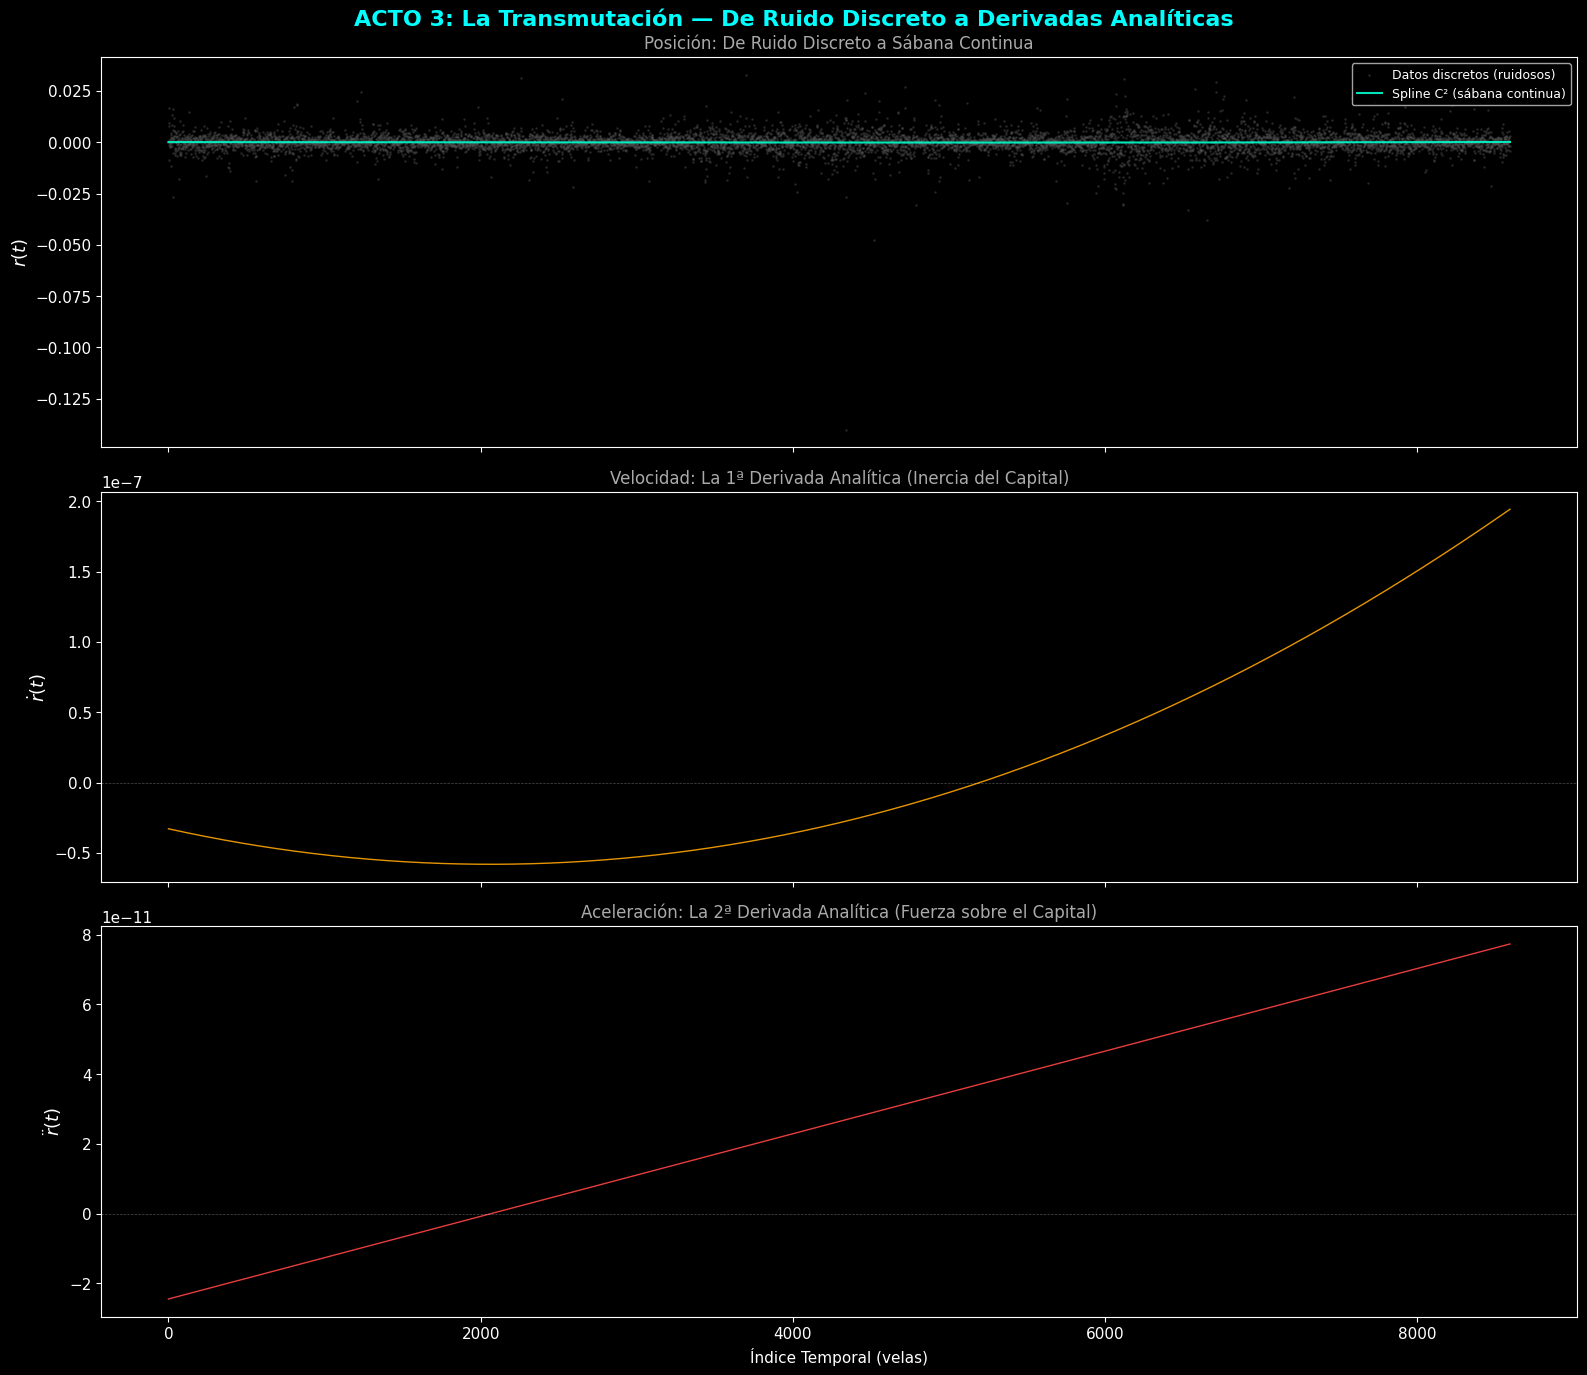

👁️ Observa cómo la nube gris de puntos se convierte en una curva suave (cyan).
   De esa curva nacen derivadas perfectas (naranja y rojo) que antes eran imposibles.


In [8]:
# === VISUALIZACIÓN: La Transmutación (Ruido → Sábana → Derivadas) ===
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.suptitle('ACTO 3: La Transmutación — De Ruido Discreto a Derivadas Analíticas', 
             fontsize=16, fontweight='bold', color='cyan')

# Subplot 1: Posición (datos crudos vs spline)
axes[0].scatter(t, log_returns, color='#555555', s=1, alpha=0.3, label='Datos discretos (ruidosos)')
axes[0].plot(t, r_smooth, color='#00FFCC', linewidth=1.5, alpha=0.9, label='Spline C² (sábana continua)')
axes[0].set_ylabel('$r(t)$', fontsize=13)
axes[0].set_title('Posición: De Ruido Discreto a Sábana Continua', fontsize=12, color='#AAAAAA')
axes[0].legend(loc='upper right', fontsize=9)

# Subplot 2: 1ª Derivada (Velocidad)
axes[1].plot(t, r_dot, color='#FFA500', linewidth=1.0, alpha=0.9)
axes[1].axhline(y=0, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
axes[1].set_ylabel('$\dot{r}(t)$', fontsize=13)
axes[1].set_title('Velocidad: La 1ª Derivada Analítica (Inercia del Capital)', fontsize=12, color='#AAAAAA')

# Subplot 3: 2ª Derivada (Aceleración)
axes[2].plot(t, r_dot2, color='#FF4444', linewidth=1.0, alpha=0.9)
axes[2].axhline(y=0, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
axes[2].set_ylabel('$\ddot{r}(t)$', fontsize=13)
axes[2].set_title('Aceleración: La 2ª Derivada Analítica (Fuerza sobre el Capital)', fontsize=12, color='#AAAAAA')
axes[2].set_xlabel('Índice Temporal (velas)', fontsize=11)

plt.tight_layout()
plt.show()

print("👁️ Observa cómo la nube gris de puntos se convierte en una curva suave (cyan).")
print("   De esa curva nacen derivadas perfectas (naranja y rojo) que antes eran imposibles.")

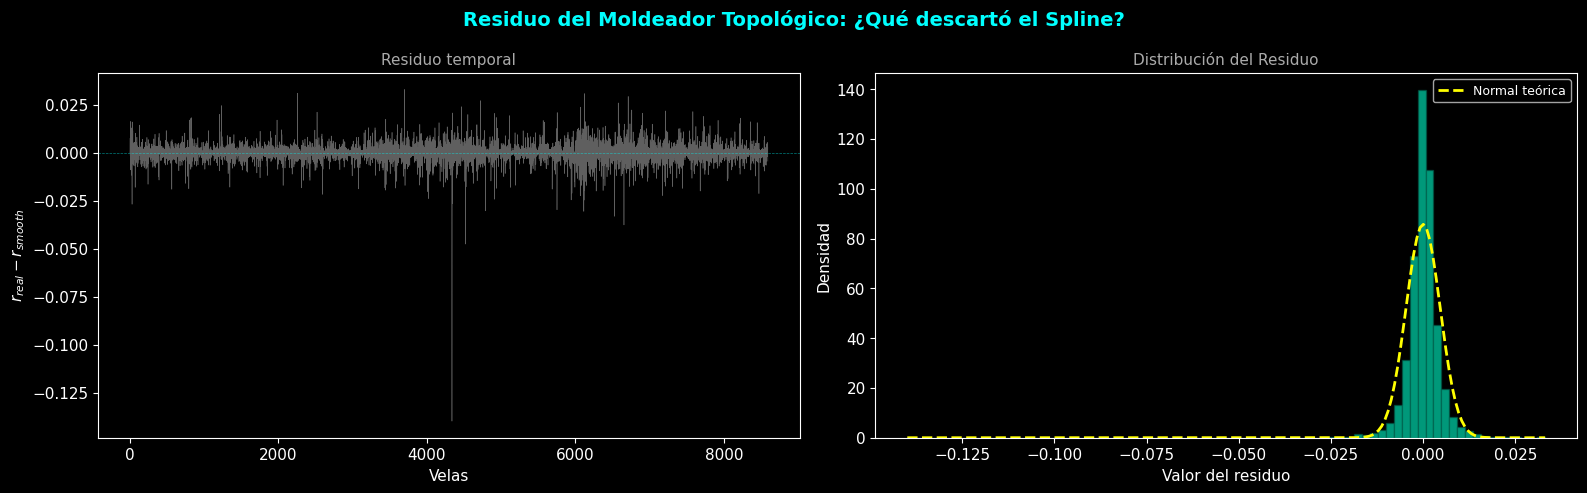

📊 σ_residuo = 0.004654
   Este valor (0.004654) será inyectado como RUIDO en la simulación Monte Carlo.


In [9]:
# === VISUALIZACIÓN: Residuo Topológico (lo que el Spline descartó) ===
residuo_spline = log_returns - r_smooth

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Residuo del Moldeador Topológico: ¿Qué descartó el Spline?', 
             fontsize=14, fontweight='bold', color='cyan')

# Plot temporal del residuo
axes[0].plot(t, residuo_spline, color='#888888', linewidth=0.4, alpha=0.7)
axes[0].axhline(y=0, color='cyan', linewidth=0.5, linestyle='--', alpha=0.5)
axes[0].set_title('Residuo temporal', fontsize=11, color='#AAAAAA')
axes[0].set_xlabel('Velas')
axes[0].set_ylabel('$r_{real} - r_{smooth}$')

# Histograma del residuo
axes[1].hist(residuo_spline, bins=80, color='#00FFCC', alpha=0.6, edgecolor='#005544', density=True)
axes[1].set_title('Distribución del Residuo', fontsize=11, color='#AAAAAA')
axes[1].set_xlabel('Valor del residuo')
axes[1].set_ylabel('Densidad')

# Superponer una curva normal teórica
from scipy.stats import norm
x_norm = np.linspace(residuo_spline.min(), residuo_spline.max(), 200)
axes[1].plot(x_norm, norm.pdf(x_norm, loc=residuo_spline.mean(), scale=residuo_spline.std()), 
            color='yellow', linewidth=2, linestyle='--', label='Normal teórica')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"📊 σ_residuo = {residuo_spline.std():.6f}")
print(f"   Este valor ({residuo_spline.std():.6f}) será inyectado como RUIDO en la simulación Monte Carlo.")

---
# 📋 ACTO 4: Sistema Nervioso — CUSUM (Capa 3)
## El Sismógrafo que Detecta Rupturas Estructurales

El mercado es de "**Equilibrio Puntuado**": la ecuación que lo gobierna hoy puede romperse mañana por un shock macroeconómico (una decisión de la Fed, un halving de Bitcoin, un cisne negro).

### Algoritmo CUSUM Bilateral:
Se calculan dos acumuladores (positivo y negativo) sobre los residuos estandarizados:

$$S^+_i = \max(0, \; S^+_{i-1} + z_i - k)$$
$$S^-_i = \max(0, \; S^-_{i-1} - z_i - k)$$

Cuando alguno de los acumuladores supera el umbral $H$, se declara una **ruptura de régimen**. El sistema purga su memoria y busca una nueva ley física.

- **$k$ (drift):** Tolerancia al ruido normal. Valores altos = más tolerante.
- **$H$ (threshold):** Umbral de ruptura. Valores altos = solo detecta cambios grandes.

In [10]:
# === EJECUTAR EL SISTEMA NERVIOSO (CUSUM) ===
CUSUM_H = 5.0    # Umbral de ruptura
CUSUM_K = 1.0    # Tolerancia al drift

detector = RegimeShiftDetector(threshold=CUSUM_H, drift=CUSUM_K)
cusum_report = detector.detect(log_returns, r_smooth)

# --- TABLA DEL REPORTE CUSUM ---
print("=" * 65)
print("  REPORTE DEL SISTEMA NERVIOSO (CUSUM)")
print("=" * 65)
print(f"  Ruptura detectada:     {cusum_report['shift_detected']}")
print(f"  Índices de ruptura:    {cusum_report['shift_indices']}")
print(f"  Triggers crudos:       {len(cusum_report['raw_triggers'])} alertas")
print(f"  Gap de clustering:     30 velas (hardcoded)")
print(f"  Runtime:               {cusum_report['runtime_ms']:.2f} ms")
n_regimes = len(cusum_report['shift_indices']) + 1
print(f"  Regímenes detectados:  {n_regimes}")
print("=" * 65)

  REPORTE DEL SISTEMA NERVIOSO (CUSUM)
  Ruptura detectada:     True
  Índices de ruptura:    [2257, 3439, 3697, 4337, 4464, 4519, 4551, 4720, 4791, 4865, 4939, 5752, 5943, 5993, 6065, 6111, 6280, 6529, 6594, 6654, 6711, 6752, 7213, 7582]
  Triggers crudos:       32 alertas
  Gap de clustering:     30 velas (hardcoded)
  Runtime:               13.27 ms
  Regímenes detectados:  25


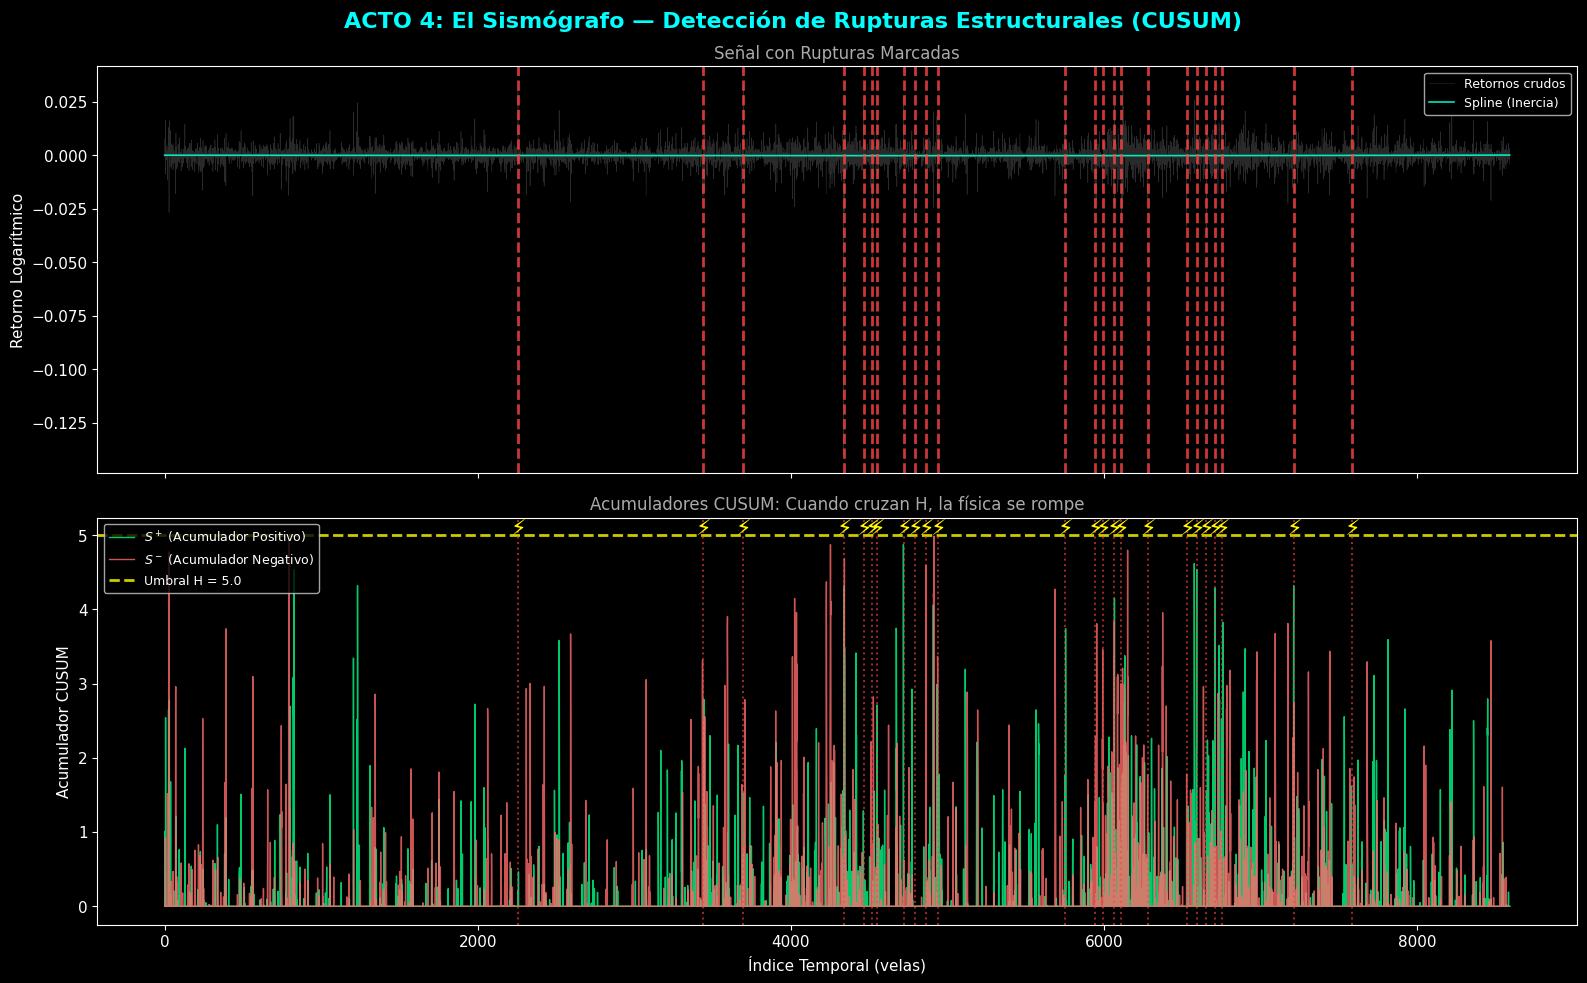

👁️ Cada línea roja punteada marca un momento donde la física del mercado cambió.
   El acumulador sube lentamente y, al cruzar H, declara la ruptura.


In [11]:
# === VISUALIZACIÓN: El Sismógrafo CUSUM ===
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('ACTO 4: El Sismógrafo — Detección de Rupturas Estructurales (CUSUM)', 
             fontsize=16, fontweight='bold', color='cyan')

# Subplot 1: Retornos con líneas de ruptura
axes[0].plot(t, log_returns, color='#555555', linewidth=0.4, alpha=0.5, label='Retornos crudos')
axes[0].plot(t, r_smooth, color='#00FFCC', linewidth=1.2, alpha=0.9, label='Spline (Inercia)')
for si in cusum_report['shift_indices']:
    axes[0].axvline(x=t[si], color='#FF4444', linewidth=2, linestyle='--', alpha=0.8)
axes[0].set_ylabel('Retorno Logarítmico', fontsize=11)
axes[0].set_title('Señal con Rupturas Marcadas', fontsize=12, color='#AAAAAA')
axes[0].legend(loc='upper right', fontsize=9)

# Subplot 2: Acumuladores CUSUM
s_pos = cusum_report['s_pos']
s_neg = cusum_report['s_neg']
axes[1].plot(t, s_pos, color='#00FF88', linewidth=1.0, alpha=0.8, label='$S^+$ (Acumulador Positivo)')
axes[1].plot(t, s_neg, color='#FF6B6B', linewidth=1.0, alpha=0.8, label='$S^-$ (Acumulador Negativo)')
axes[1].axhline(y=CUSUM_H, color='yellow', linewidth=2, linestyle='--', alpha=0.8, label=f'Umbral H = {CUSUM_H}')
for si in cusum_report['shift_indices']:
    axes[1].axvline(x=t[si], color='#FF4444', linewidth=1.5, linestyle=':', alpha=0.6)
    axes[1].annotate('⚡', xy=(t[si], CUSUM_H), fontsize=16, color='yellow', ha='center')
axes[1].set_ylabel('Acumulador CUSUM', fontsize=11)
axes[1].set_xlabel('Índice Temporal (velas)', fontsize=11)
axes[1].set_title('Acumuladores CUSUM: Cuando cruzan H, la física se rompe', fontsize=12, color='#AAAAAA')
axes[1].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print("👁️ Cada línea roja punteada marca un momento donde la física del mercado cambió.")
print("   El acumulador sube lentamente y, al cruzar H, declara la ruptura.")

---
# 📋 ACTO 5: Preparación de las Matrices de Estado
## El Banquete que Servimos a SINDy

Antes de que SINDy pueda descubrir la ley física, debemos empaquetar nuestras señales continuas en dos matrices perfectas:

- **Matriz de Estados** $X$: Contiene la posición suavizada y el volumen suavizado → `[r_smooth, v_smooth]`
- **Matriz de Derivadas** $\dot{X}$: Contiene las derivadas analíticas → `[r_dot, v_dot]`
- **Ruido Residual** $\sigma_{res}$: La desviación estándar de lo que el Spline descartó (se inyectará en Monte Carlo)

SINDy se preguntará: *"¿Qué combinación polinomial de $X$ necesito sumar y restar para igualar exactamente a $\dot{X}$?"*

In [12]:
# === PREPARAR LAS MATRICES DE ESTADO PARA SINDy ===
x_matrix = np.column_stack((r_smooth, v_smooth))
x_dot_matrix = np.column_stack((r_dot, v_dot))

# Calcular el nivel de ruido residual
sigma_res_r = float(np.std(log_returns - r_smooth))
sigma_res_v = float(np.std(volumen_z - v_smooth))

# --- TABLA DE INSPECCIÓN PRE-SINDy ---
print("=" * 65)
print("  INSPECCIÓN PRE-SINDy: MATRICES DE ESTADO")
print("=" * 65)
print(f"  x_matrix     → shape: {x_matrix.shape}  | Columnas: [r_smooth, v_smooth]")
print(f"  x_dot_matrix → shape: {x_dot_matrix.shape}  | Columnas: [r_dot, v_dot]")
print(f"  σ_residual_r → {sigma_res_r:.6f} (ruido para Monte Carlo - canal retornos)")
print(f"  σ_residual_v → {sigma_res_v:.6f} (ruido para Monte Carlo - canal volumen)")
print("=" * 65)

  INSPECCIÓN PRE-SINDy: MATRICES DE ESTADO
  x_matrix     → shape: (8593, 2)  | Columnas: [r_smooth, v_smooth]
  x_dot_matrix → shape: (8593, 2)  | Columnas: [r_dot, v_dot]
  σ_residual_r → 0.004654 (ruido para Monte Carlo - canal retornos)
  σ_residual_v → 0.997097 (ruido para Monte Carlo - canal volumen)


<>:15: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:15: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\ussaa\AppData\Local\Temp\ipykernel_13788\3990747198.py:15: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  ax.set_ylabel('Velocidad del Retorno ($\dot{r}$)', fontsize=12)


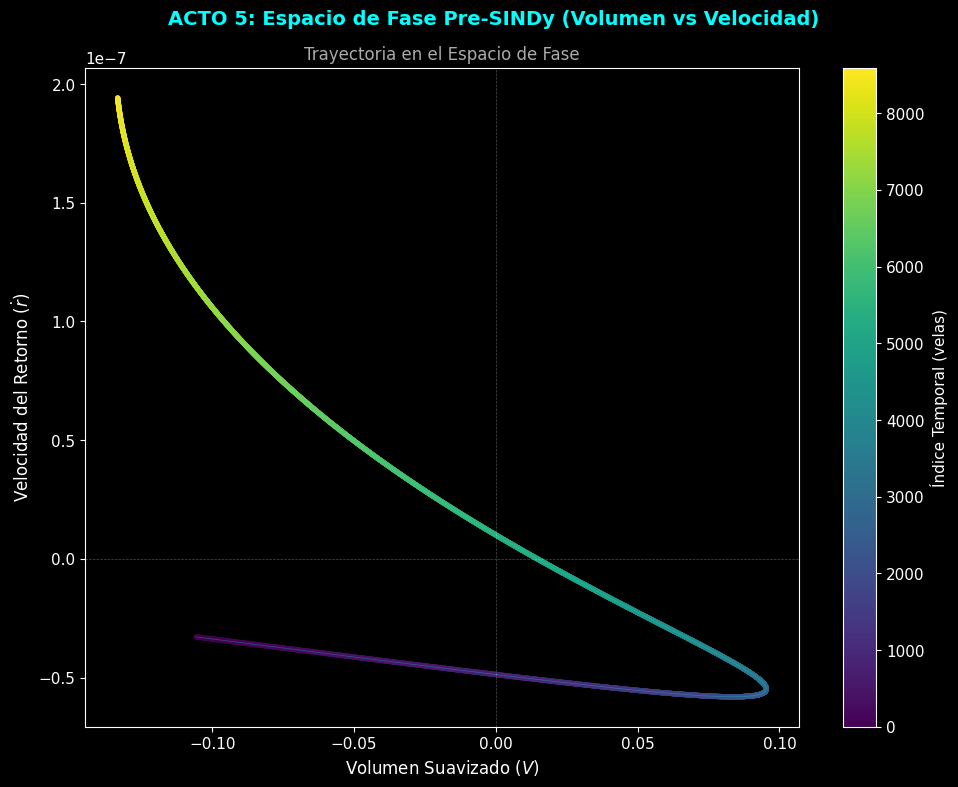

👁️ Si ves una órbita definida → hay inercia explotable.
   Si ves un ovillo caótico → el mercado es ruido puro.


In [13]:
# === VISUALIZACIÓN: Espacio de Fase Pre-SINDy ===
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
fig.suptitle('ACTO 5: Espacio de Fase Pre-SINDy (Volumen vs Velocidad)', 
             fontsize=14, fontweight='bold', color='cyan')

# Gradiente temporal (Viridis): oscuro = pasado, amarillo = presente
norm = Normalize(vmin=0, vmax=len(t))
colors = cm.viridis(norm(np.arange(len(t))))

ax.scatter(v_smooth, r_dot, c=colors, s=8, alpha=0.6)
ax.plot(v_smooth, r_dot, color='#00FFCC', linewidth=0.5, alpha=0.3)
ax.axhline(y=0, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
ax.axvline(x=0, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
ax.set_xlabel('Volumen Suavizado ($V$)', fontsize=12)
ax.set_ylabel('Velocidad del Retorno ($\dot{r}$)', fontsize=12)
ax.set_title('Trayectoria en el Espacio de Fase', fontsize=12, color='#AAAAAA')

# Colorbar para el tiempo
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Índice Temporal (velas)')

plt.tight_layout()
plt.show()

print("👁️ Si ves una órbita definida → hay inercia explotable.")
print("   Si ves un ovillo caótico → el mercado es ruido puro.")

---
# 📋 ACTO 6: Descubrimiento Físico — SINDy (Capa 4, Parte 1)
## El Corazón del Motor: Encontrando la Ley de Gravedad del Mercado

**SINDy** (Sparse Identification of Nonlinear Dynamics) construye una biblioteca de funciones polinómicas candidatas y usa **Regresión Rala (STLSQ)** para tachar implacablemente los términos inútiles, dejando solo la ecuación más espartana que explica los datos.

### Biblioteca Polinomial (grado 2):
$$\Theta(X) = [1, \; r, \; V, \; r^2, \; r \cdot V, \; V^2]$$

### Lo que SINDy resuelve:
$$\dot{X} = \Theta(X) \cdot \Xi$$

Donde $\Xi$ es la matriz de coeficientes espartanos.

### Auto-calibración:
El motor prueba 7 umbrales STLSQ distintos `[0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]` y elige el que maximiza $R^2$.

### Escalado Interno:
Los retornos logarítmicos son microscópicos (~0.001). Para evitar que STLSQ los aniquile, se escalan ×100 internamente (a porcentajes).

In [14]:
# === EJECUTAR SINDy (DESCUBRIMIENTO FÍSICO) ===
POLY_DEGREE = 2
HORIZON_STEPS = 50  # Proyectar 50 velas al futuro

discoverer = PhysicsDiscoverer(poly_degree=POLY_DEGREE)

# Ejecutar sobre el ÚLTIMO RÉGIMEN (si hay rupturas CUSUM) o todo el histórico
boundaries = [0] + cusum_report['shift_indices'] + [len(t)]
last_start = boundaries[-2]
last_end = boundaries[-1]

# Asegurar que el régimen activo tenga al menos 15 muestras
if last_end - last_start < 15:
    last_start = 0  # Fallback al histórico completo

t_active = t[last_start:last_end]
x_active = x_matrix[last_start:last_end]
x_dot_active = x_dot_matrix[last_start:last_end]
local_sigma_r = float(np.std(log_returns[last_start:last_end] - r_smooth[last_start:last_end]))
local_sigma_v = float(np.std(volumen_z[last_start:last_end] - v_smooth[last_start:last_end]))

physics_report = discoverer.extract_equations(
    t=t_active, x=x_active, x_dot=x_dot_active, dt=dt,
    horizon_steps=HORIZON_STEPS, sigma_res_r=local_sigma_r, sigma_res_v=local_sigma_v,
    last_price=precio_raw[-1]
)

# --- MOSTRAR LA ECUACIÓN DESCUBIERTA ---
print("\n" + "╔" + "═" * 60 + "╗")
print("║  ECUACIÓN DESCUBIERTA POR SINDy" + " " * 29 + "║")
print("╠" + "═" * 60 + "╣")
for i, eq in enumerate(physics_report['equations']):
    var = 'dr/dt' if i == 0 else 'dV/dt'
    print(f"║  {var} = {eq:52s}  ║")
print("╠" + "═" * 60 + "╣")
print(f"║  Score (R²)        = {physics_report['score']:.4f}" + " " * 34 + "║")
print(f"║  Complejidad       = {physics_report['complexity']} coeficientes no-zero" + " " * 20 + "║")
print(f"║  Threshold STLSQ   = {physics_report['threshold_used']}" + " " * (37 - len(str(physics_report['threshold_used']))) + "║")
print(f"║  Física estable    = {not physics_report['prediction']['unstable']}" + " " * (37 - len(str(not physics_report['prediction']['unstable']))) + "║")
print(f"║  Runtime           = {physics_report['runtime_ms']:.1f} ms" + " " * (33 - len(f"{physics_report['runtime_ms']:.1f}")) + "║")
print("╚" + "═" * 60 + "╝")

if physics_report.get('empty_r_eq'):
    print("\n⚠️  ADVERTENCIA: SINDy anuló la ecuación de retornos (dr/dt = 0).")
    print("   Esto indica que el mercado se comporta como ruido puro en este régimen.")

Física Débil/Inexistente (R2=-28.01). Evitando iteración Monte Carlo por Alucinación Matemática.
Falso Positivo Estocástico Detectado: SINDy anuló los Retornos (dr/dt = 0). Bloqueando cono divergente.



╔════════════════════════════════════════════════════════════╗
║  ECUACIÓN DESCUBIERTA POR SINDy                             ║
╠════════════════════════════════════════════════════════════╣
║  dr/dt =  0.00000                                              ║
║  dV/dt = -0.00539 1 +  0.26978 r + -0.00003 V + -0.00048 r V   ║
╠════════════════════════════════════════════════════════════╣
║  Score (R²)        = -28.0061                                  ║
║  Complejidad       = 5 coeficientes no-zero                    ║
║  Threshold STLSQ   = 0.0001                               ║
║  Física estable    = False                                ║
║  Runtime           = 131.3 ms                            ║
╚════════════════════════════════════════════════════════════╝

⚠️  ADVERTENCIA: SINDy anuló la ecuación de retornos (dr/dt = 0).
   Esto indica que el mercado se comporta como ruido puro en este régimen.


<>:25: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:26: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:25: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:26: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\ussaa\AppData\Local\Temp\ipykernel_13788\3208185508.py:25: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  axes[0].plot(t_active, x_dot_real_scaled[:, 0], color='#555555', linewidth=0.5, alpha=0.6, label='$\dot{r}$ real (escalado)')
C:\Users\ussaa\AppData\Local\Temp\ipykern

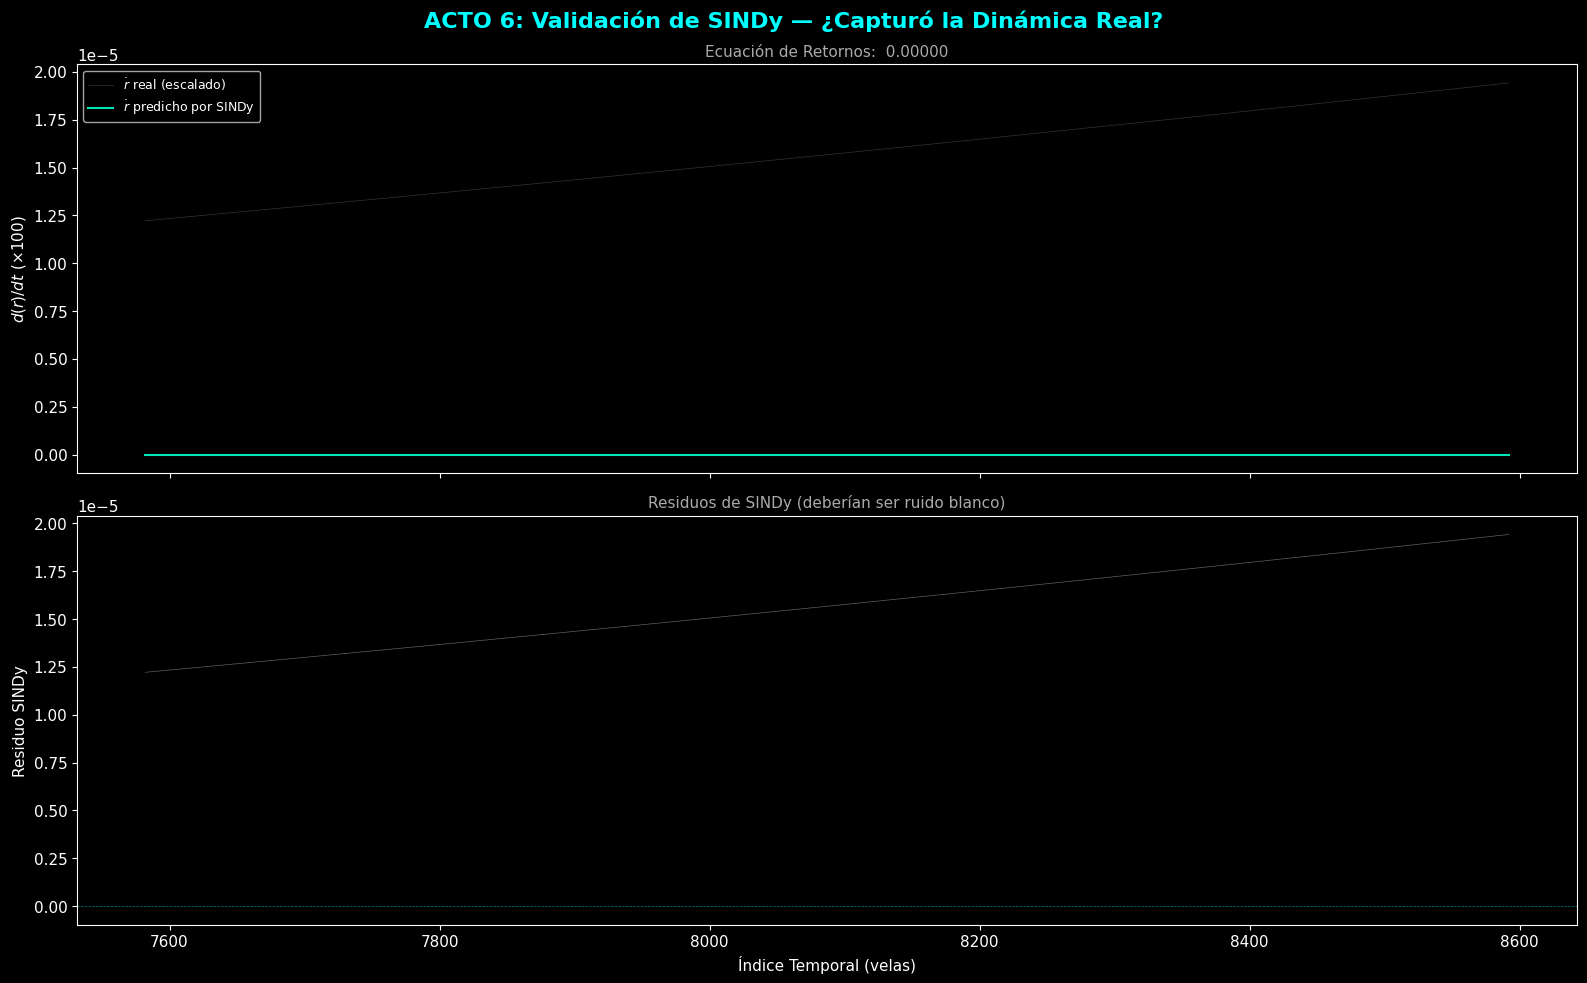

📊 R² de SINDy = -28.0061
   Si R² > 0.5: SINDy encontró una ley física significativa.
   Si R² < 0.05: El mercado es ruido puro (Kill-Switch activado).


In [15]:
# === VISUALIZACIÓN: Ajuste de SINDy vs Derivadas Reales ===
# Reconstruir la predicción de SINDy sobre los datos de entrenamiento
import pysindy as ps

# Predecir las derivadas usando el modelo ajustado
x_scaled_viz = x_active.copy()
x_scaled_viz[:, 0] = x_active[:, 0] * 100.0  # Escalado 100x
mu_v_viz = np.mean(x_active[:, 1])
sigma_v_viz = np.std(x_active[:, 1])
if sigma_v_viz < 1e-8: sigma_v_viz = 1.0
x_scaled_viz[:, 1] = (x_active[:, 1] - mu_v_viz) / sigma_v_viz

x_dot_pred = discoverer.model.predict(x_scaled_viz)

# Des-escalar para comparar
x_dot_real_scaled = x_dot_active.copy()
x_dot_real_scaled[:, 0] = x_dot_active[:, 0] * 100.0
x_dot_real_scaled[:, 1] = x_dot_active[:, 1] / sigma_v_viz

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('ACTO 6: Validación de SINDy — ¿Capturó la Dinámica Real?', 
             fontsize=16, fontweight='bold', color='cyan')

# dr/dt: real vs predicho
axes[0].plot(t_active, x_dot_real_scaled[:, 0], color='#555555', linewidth=0.5, alpha=0.6, label='$\dot{r}$ real (escalado)')
axes[0].plot(t_active, x_dot_pred[:, 0], color='#00FFCC', linewidth=1.5, alpha=0.9, label='$\dot{r}$ predicho por SINDy')
axes[0].set_ylabel('$d(r)/dt$ (×100)', fontsize=11)
axes[0].set_title(f'Ecuación de Retornos: {physics_report["equations"][0]}', fontsize=11, color='#AAAAAA')
axes[0].legend(fontsize=9)

# Residuos
residuo_sindy = x_dot_real_scaled[:, 0] - x_dot_pred[:, 0]
axes[1].plot(t_active, residuo_sindy, color='#888888', linewidth=0.5, alpha=0.7)
axes[1].axhline(y=0, color='cyan', linewidth=0.5, linestyle='--', alpha=0.5)
axes[1].set_ylabel('Residuo SINDy', fontsize=11)
axes[1].set_xlabel('Índice Temporal (velas)', fontsize=11)
axes[1].set_title('Residuos de SINDy (deberían ser ruido blanco)', fontsize=11, color='#AAAAAA')

plt.tight_layout()
plt.show()

print(f"📊 R² de SINDy = {physics_report['score']:.4f}")
print(f"   Si R² > 0.5: SINDy encontró una ley física significativa.")
print(f"   Si R² < 0.05: El mercado es ruido puro (Kill-Switch activado).")

---
# 📋 ACTO 7: Proyección Monte Carlo — Euler-Maruyama (Capa 4, Parte 2)
## De la Ecuación del Presente al Cono del Futuro

Ahora que SINDy nos dio la ecuación determinista, la lanzamos al futuro inyectándole incertidumbre. 

### La Ecuación de Euler-Maruyama:
$$r_{t+1} = r_t + \underbrace{f_{SINDy}(r_t, V_t) \cdot \Delta t}_{\text{Drift Determinista}} + \underbrace{\sigma_{res} \cdot \sqrt{\Delta t} \cdot \mathcal{N}(0,1)}_{\text{Ruido Estocástico}}$$

### Proceso:
1. Tomar el último estado conocido y clonarlo **1,000 veces** (trayectorias paralelas).
2. En cada paso temporal, SINDy calcula el drift + inyectamos ruido gaussiano.
3. Repetir durante `horizon_steps` pasos.
4. De las 1,000 trayectorias, extraer percentiles: $P_5, P_{25}, P_{50}, P_{75}, P_{95}$.
5. Reconstruir el precio: $\text{Precio} = P_{\text{último}} \cdot e^{\sum r}$.

In [16]:
# === VISUALIZACIÓN: El Cono Estocástico ===
pred = physics_report['prediction']

if not pred['unstable'] and len(pred['price_percentiles']) > 0:
    p_percentiles = np.array(pred['price_percentiles'])  # (5, horizon)
    t_pred = np.array(pred['t_path'])
    
    # Construir el eje temporal completo (pasado + futuro)
    fig, ax = plt.subplots(1, 1, figsize=(16, 8))
    fig.suptitle('ACTO 7: El Cono Estocástico — 1,000 Universos Paralelos', 
                 fontsize=16, fontweight='bold', color='cyan')
    
    # Precio histórico real
    ax.plot(t, precio_raw, color='white', linewidth=1.0, alpha=0.8, label='Precio Real (Pasado)')
    
    # Trayectoria determinista (ecuación desnuda sin ruido)
    if len(pred['det_price_path']) > 0:
        det_t = np.array(pred['det_t_path'])
        det_p = np.array(pred['det_price_path'])
        ax.plot(det_t, det_p, color='#00FFCC', linewidth=2, linestyle='--', alpha=0.9, 
                label='Determinista (Ecuación Pura)')
    
    # Bandas del cono
    ax.fill_between(t_pred, p_percentiles[0], p_percentiles[4], alpha=0.15, color='cyan', label='$P_5 - P_{95}$')
    ax.fill_between(t_pred, p_percentiles[1], p_percentiles[3], alpha=0.25, color='cyan', label='$P_{25} - P_{75}$')
    ax.plot(t_pred, p_percentiles[2], color='yellow', linewidth=2, alpha=0.9, label='$P_{50}$ (Mediana)')
    
    # Línea vertical de separación pasado/futuro
    ax.axvline(x=t[-1], color='#FF4444', linewidth=1.5, linestyle=':', alpha=0.7, label='Horizonte (Presente)')
    
    ax.set_xlabel('Índice Temporal', fontsize=12)
    ax.set_ylabel('Precio (USD)', fontsize=12)
    ax.legend(loc='upper left', fontsize=9)
    ax.set_title(f'Proyección Monte Carlo: {HORIZON_STEPS} velas al futuro | 1,000 trayectorias', 
                fontsize=12, color='#AAAAAA')
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas del cono
    print(f"\n📊 Estadísticas del Cono Estocástico (Último paso):")
    print(f"   P₅  = ${p_percentiles[0, -1]:,.2f}  (Escenario pesimista)")
    print(f"   P₂₅ = ${p_percentiles[1, -1]:,.2f}")
    print(f"   P₅₀ = ${p_percentiles[2, -1]:,.2f}  (Mediana)")
    print(f"   P₇₅ = ${p_percentiles[3, -1]:,.2f}")
    print(f"   P₉₅ = ${p_percentiles[4, -1]:,.2f}  (Escenario optimista)")
    print(f"   Spread P₅-P₉₅ = ${p_percentiles[4, -1] - p_percentiles[0, -1]:,.2f} (Anchura de incertidumbre)")
else:
    print("⚠️  Monte Carlo fue abortado: física inestable detectada (R² < 0.05).")
    print("   El motor activó el Kill-Switch Anti-Alucinaciones.")
    print(f"   R² obtenido: {physics_report['score']:.4f}")

⚠️  Monte Carlo fue abortado: física inestable detectada (R² < 0.05).
   El motor activó el Kill-Switch Anti-Alucinaciones.
   R² obtenido: -28.0061


---
# 📋 ACTO 8: El Atractor de Espacio de Fase
## El Radar Topológico del Mercado

El **Espacio de Fase** es un gráfico donde cada eje representa una variable de estado (ej. Volumen vs Velocidad del retorno). La trayectoria temporal dibuja una "órbita" que revela la naturaleza dinámica del sistema:

- **Ovillo caótico centrado en (0,0):** Equilibrio → el mercado es ruido puro, no hay inercia explotable.
- **Órbita cerrada (espiral):** Ciclo → el mercado oscila con un período determinista.
- **Escape del centro:** Tendencia → una fuerza unidireccional domina el mercado.

<>:26: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:26: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\ussaa\AppData\Local\Temp\ipykernel_13788\229343056.py:26: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  ax.set_ylabel('Velocidad del Retorno ($\dot{r}$)', fontsize=13)


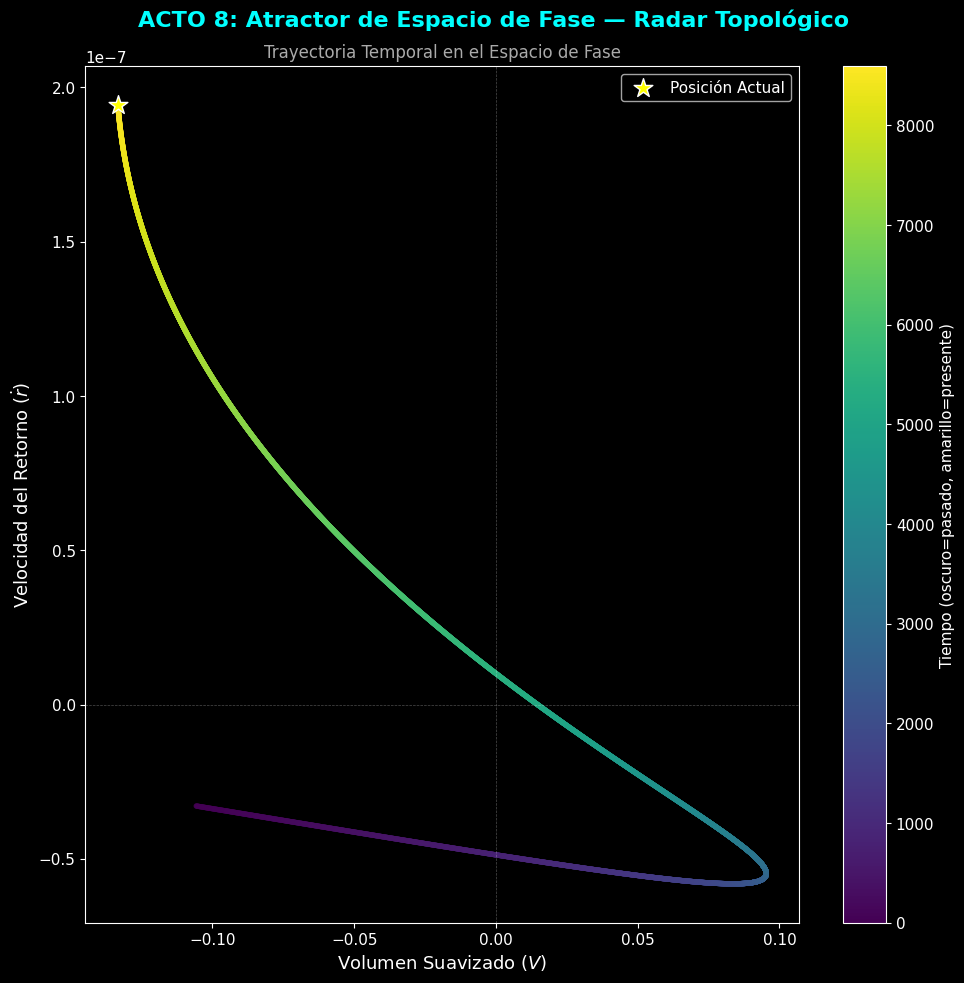

👁️ Interpretación del atractor:
   • Si la trayectoria forma una espiral → ciclo con inercia (OPORTUNIDAD)
   • Si es un ovillo denso en el centro → ruido puro (NO OPERAR)
   • Si sale disparada del centro → tendencia fuerte (SEGUIR LA FUERZA)


In [17]:
# === VISUALIZACIÓN: Atractor de Espacio de Fase (Radar de Neón) ===
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
fig.suptitle('ACTO 8: Atractor de Espacio de Fase — Radar Topológico', 
             fontsize=16, fontweight='bold', color='cyan')

# Gradiente temporal (Viridis)
norm_t = Normalize(vmin=0, vmax=len(t))
colors_t = cm.viridis(norm_t(np.arange(len(t))))

# Línea conectora
ax.plot(v_smooth, r_dot, color='#00FFCC', linewidth=0.8, alpha=0.4, zorder=1)

# Puntos con gradiente temporal
scatter = ax.scatter(v_smooth, r_dot, c=np.arange(len(t)), cmap='viridis', 
                     s=15, alpha=0.7, zorder=2, edgecolors='none')

# Ejes de referencia
ax.axhline(y=0, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
ax.axvline(x=0, color='white', linewidth=0.5, linestyle='--', alpha=0.3)

# Marcar el punto actual (último punto) con un marcador grande
ax.scatter([v_smooth[-1]], [r_dot[-1]], color='yellow', s=200, marker='*', 
           zorder=3, edgecolors='white', linewidths=1, label='Posición Actual')

ax.set_xlabel('Volumen Suavizado ($V$)', fontsize=13)
ax.set_ylabel('Velocidad del Retorno ($\dot{r}$)', fontsize=13)
ax.set_title('Trayectoria Temporal en el Espacio de Fase', fontsize=12, color='#AAAAAA')
ax.legend(loc='upper right', fontsize=11)

# Colorbar
sm = cm.ScalarMappable(cmap='viridis', norm=norm_t)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Tiempo (oscuro=pasado, amarillo=presente)')

plt.tight_layout()
plt.show()

print("👁️ Interpretación del atractor:")
print("   • Si la trayectoria forma una espiral → ciclo con inercia (OPORTUNIDAD)")
print("   • Si es un ovillo denso en el centro → ruido puro (NO OPERAR)")
print("   • Si sale disparada del centro → tendencia fuerte (SEGUIR LA FUERZA)")

---
# 📋 ACTO 9: Solución Analítica — SymPy
## Intentando Resolver la ODE de Forma Cerrada

El `SymbolicTranslator` toma la ecuación descubierta por SINDy e intenta resolverla analíticamente usando **SymPy** (la librería de matemáticas simbólicas de Python). Si lo logra, obtenemos una fórmula cerrada $r(t) = ...$ en lugar de depender de la integración numérica.

> ⚠️ **Nota:** Esta sección puede fallar si la ecuación es demasiado compleja para SymPy (timeout de 2 segundos). Es un intento legítimo, no una garantía.

In [18]:
# === SOLUCIÓN ANALÍTICA CON SYMPY ===
symbolic = SymbolicTranslator(physics_report)

p0 = log_returns[-1]
v0 = v_smooth[-1]

print("=" * 65)
print("  INTENTO DE SOLUCIÓN ANALÍTICA (SymPy)")
print("=" * 65)
print(f"  Condiciones iniciales: r₀ = {p0:.6f}, V₀ = {v0:.6f}")
print()

try:
    analytical_solution = symbolic.generate_analytical_solution(p0=p0, v0=v0, disable_returns=False)
    print("  Resultado:")
    print(f"  {analytical_solution}")
except Exception as e:
    print(f"  ⚠️ SymPy no pudo resolver la ODE: {e}")
    print("  Esto es normal para ecuaciones no-lineales complejas.")

print()
print("=" * 65)

# Comandos GeoGebra (opcional)
print("\n📐 Comandos GeoGebra para visualización externa:")
try:
    geogebra_cmds = symbolic.generate_geogebra_commands()
    # Mostrar solo las primeras líneas
    lines = geogebra_cmds.strip().split('\n')
    for line in lines[:10]:
        print(f"   {line}")
    if len(lines) > 10:
        print(f"   ... ({len(lines) - 10} líneas más)")
except Exception as e:
    print(f"   ⚠️ Error generando comandos GeoGebra: {e}")

  INTENTO DE SOLUCIÓN ANALÍTICA (SymPy)
  Condiciones iniciales: r₀ = -0.004133, V₀ = -0.133351

  Resultado:
  Sistema Caótico Irresoluble: La EDO cruzada no posee solución analítica cerrada (Típicamente Ocurre en polinomios grado >= 2).
Utilizar Fallback Numérico.


📐 Comandos GeoGebra para visualización externa:
   Campo de Direcciones (Retorno vs Tiempo):
   1) dr_dt_temporal(x, y, Vol) =  0.00000  // (Sustituir 'Vol' por constante o función)
      Campo1 = CampoDirecciones(dr_dt_temporal)
   
   Campo de Direcciones Espacio de Fase (X = Volumen, Y = Retorno):
   2) dy_dx(x, y) = ( 0.00000) / (-0.00539 1.0 +  0.26978 y + -0.00003 x + -0.00048 y x)
      Atractor = CampoDirecciones(dy_dx)


---
# 📋 ACTO 10: Tabla de Hiperparámetros y Conclusiones
## Mapa Completo de las Constantes del Motor

Esta tabla consolida **TODOS** los números mágicos del Kinetopus Engine en un solo lugar auditable. Cualquier reformulación futura debe evaluar el impacto de modificar estos valores.

| Constante | Archivo | Valor | Propósito |
|---|---|---|---|
| `EPSILON` | market_loader.py | `1e-8` | Protección contra división por cero |
| `top_k` | app.py | `2` | Frecuencias FFT dominantes por canal |
| `s` (Spline) | blender.py | `period × N × tol × 0.1` | Parámetro de suavizado del Spline |
| Grado Spline | blender.py | `3` (cúbico) | Orden del polinomio del Spline |
| CUSUM `H` | nervous.py | UI (default 5.0) | Umbral de ruptura de régimen |
| CUSUM `k` | nervous.py | UI (default 1.0) | Tolerancia al drift (ruido normal) |
| Gap clustering | nervous.py | `30` velas | Ventana de silencio entre alertas |
| Estimador σ | nervous.py | `std(diff) / √2` | Estimación robusta del ruido |
| Escalado 100x | physics.py | `100.0` | Log-return → porcentaje para STLSQ |
| Grid STLSQ | physics.py | `[0.1, ..., 0.0001]` | Auto-calibración del umbral de esparcidad |
| L2 Alpha | physics.py | `0.05` | Regularización Ridge (previene sobreajuste) |
| R² Kill-Switch | physics.py | `0.05` | Por debajo = física inestable |
| MC Trayectorias | physics.py | `1000` | Caminos de Monte Carlo simultáneos |
| State Clamp | physics.py | `±10.0` | Límite de las variables de estado |
| Noise Clip | physics.py | `±3σ` | Clip del ruido gaussiano |
| Guard Determinista | physics.py | `1e10` | Máximo absoluto antes de abortar |
| Guard Estocástico | physics.py | `1e6` | Máximo absoluto antes de abortar MC |
| Régimen mínimo | app.py | `15` muestras | Mínimo de velas para que SINDy opere |
| Rescue tolerances | app.py | `[5e-4, 1e-4, 5e-5]` | Tolerancias de rescate automático |
| SymPy timeout | symbolic.py | `2.0` s | Tiempo máximo para solución analítica |

---

## 🎯 Vectores de Ataque para Reformulación

### Áreas más sensibles:
1. **El escalado 100x** (physics.py): Es un "hotfix" que funciona pero es frágil. Si cambias el tipo de datos de entrada, este factor puede hacer que SINDy descarte señales válidas.
2. **El Gap de Clustering de 30 velas** (nervous.py): Es una constante hardcodeada. Para diferentes timeframes (1d vs 1h) este valor debería ser dinámico.
3. **La fórmula del parámetro `s` del Spline** (blender.py): Depende linealmente del período de la FFT. Si la FFT detecta períodos erróneos, el Spline suavizará demasiado o demasiado poco.

### Áreas más robustas:
1. **El Grid Search de STLSQ**: Auto-calibra el umbral de esparcidad. Es la defensa más sólida contra el sobreajuste.
2. **El Kill-Switch de R²**: Previene que Monte Carlo alucine cuando no hay física real.
3. **La reconstrucción de precio vía exponencial**: Matemáticamente exacta por definición de log-returns.

In [19]:
# === RESUMEN FINAL DEL PIPELINE ===
print("\n" + "=" * 70)
print("  🔬 RESUMEN DE LA AUTOPSIA MATEMÁTICA DEL KINETOPUS ENGINE")
print("=" * 70)
print(f"  Activo analizado:        {TICKER}")
print(f"  Velas procesadas:        {len(log_returns)}")
print(f"  Regímenes detectados:    {len(cusum_report['shift_indices']) + 1}")
print(f"  Ecuación SINDy:          {physics_report['equations'][0]}")
print(f"  Score R²:                {physics_report['score']:.4f}")
print(f"  Complejidad:             {physics_report['complexity']} coeficientes")
print(f"  Física estable:          {not physics_report['prediction']['unstable']}")
print(f"  σ residual (retornos):   {sigma_res_r:.6f}")
print(f"  σ residual (volumen):    {sigma_res_v:.6f}")
if not physics_report['prediction']['unstable'] and len(physics_report['prediction']['price_percentiles']) > 0:
    p = np.array(physics_report['prediction']['price_percentiles'])
    print(f"  Cono P₅₀ (t+{HORIZON_STEPS}):       ${p[2, -1]:,.2f}")
    print(f"  Spread P₅-P₉₅:          ${p[4, -1] - p[0, -1]:,.2f}")
print("=" * 70)
print("\n✅ Autopsia completada. El motor ha sido expuesto de punta a punta.")
print("   Cada número, cada array, cada decisión matemática ha sido revelada.")


  🔬 RESUMEN DE LA AUTOPSIA MATEMÁTICA DEL KINETOPUS ENGINE
  Activo analizado:        BTC-USD
  Velas procesadas:        8593
  Regímenes detectados:    25
  Ecuación SINDy:           0.00000
  Score R²:                -28.0061
  Complejidad:             5 coeficientes
  Física estable:          False
  σ residual (retornos):   0.004654
  σ residual (volumen):    0.997097

✅ Autopsia completada. El motor ha sido expuesto de punta a punta.
   Cada número, cada array, cada decisión matemática ha sido revelada.
